In [2]:
import cvxpy as cp
import numpy as np

# 定义参数
P = np.array([[4, 1],
              [1, 2]], dtype=float)    # 对称正定矩阵
q = np.array([1.0, 1.0], dtype=float)  # 线性项

# 定义优化变量
x = cp.Variable(2)

# 构造目标函数： 0.5 * x^T P x + q^T x
objective = cp.Minimize(0.5 * cp.quad_form(x, P) + q.T @ x)

# 约束条件：和为1，且非负
constraints = [
    cp.sum(x) == 1,
    x >= 0
]

# 构建并求解问题
prob = cp.Problem(objective, constraints)
# result = prob.solve(solver=cp.ECOS)  # ECOS 比较稳定
result = prob.solve()  # ECOS 比较稳定

# 输出结果
print("Optimal x =", x.value)
print("Optimal objective value =", result)


Optimal x = [0.25 0.75]
Optimal objective value = 1.875


### 这里的cvxpy 和 solver 需要单独安装
### ECOS 是个比较稳定的优化算法，精度高、效率适中，非常适合线性规划和二次规划

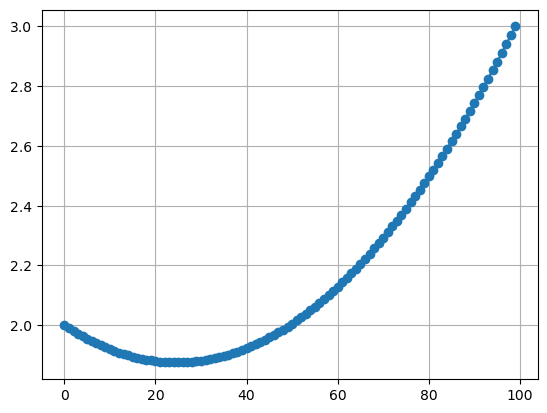

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 定义二次规划参数
P = np.array([[4, 1],
              [1, 2]], dtype=float)
q = np.array([1.0, 1.0], dtype=float)

n_samples = 100
x1_vals = np.linspace(0, 1, n_samples)
x1_vals
x2_vals = 1 - x1_vals
x_samples = np.column_stack((x1_vals, x2_vals))


# 计算目标函数值：0.5 * x^T P x + q^T x
# obj_vals = [0.5 * x.T @ P @ x + q.T @ x for x in x_samples]

obj_vals = []
for x in x_samples:
    obj = 0.5 * x.T @ P @ x + q.T @ x
    obj_vals.append(obj)
obj_vals

# 构建 DataFrame 并打印
df = pd.DataFrame(x_samples, columns=['x1', 'x2'])
df['objective'] = obj_vals
# df
# print(df.loc[df['objective'] <= 1.876])

# 绘制 objective 值随样本编号的变化
plt.figure()
plt.plot(df.index, df['objective'], marker='o')
plt.grid(True)
plt.show()


# 思考几个问题：

### - 中性是什么意思？
在 alpha 策略中，“中性”通常是指对某些已知系统性风险因子或市场暴露做对冲或控制，使得策略的收益主要来源于“alpha”本身，而不受这些因子波动的影响。这在多因子选股、量化对冲中非常关键。

### - 为什么因子已经市值中性了，还要constrain？
### - 具体选哪些因子来中性化？


## “指数增强”策略｜
- 有alpha策略优势
- 不需要对冲 (因为对冲本身有5%左右的成本)


In [11]:
# 1) 市值 & 交易日 & 月末列表
mcap       = pd.read_csv('market_cap.csv', index_col=0, parse_dates=False)

#  交易日
trade_days = mcap.index


# 2) 收盘价 → 月度收益
price      = pd.read_csv('s_dq_adjclose_v2.csv', index_col=0, parse_dates=False)
price_m    = price.loc[trade_days]
ret_m      = price_m.shift(-1) / price_m - 1
size_factor = np.log(mcap)

In [12]:
import pandas as pd
import cvxpy as cp
import numpy as np


data = pd.read_csv("factor_value_fmsq_1Y.csv", index_col=0)
factor = data.reindex(index=ret_m.index, columns=ret_m.columns)

# 结果保存
w_dict = {}
w_dict_base = {}

# 遍历每期（按行）
for dt, ret_row in ret_m.iterrows():
    # 1. 选出当期有效的股票（非 NaN）
    valid = ret_row.dropna().index.tolist()

    if len(valid) == 0:
        continue  # 跳过空期

    # 2. 提取因子值
    f_row = factor.loc[dt].reindex(valid).fillna(0).values  # 因子值
    n = len(valid)

    # 3. 决策变量：股票权重
    w = cp.Variable(n)

    # 4. 目标函数：最大化 ∑(因子 × 权重)
    obj = cp.Maximize(f_row @ w)

    # 5. 约束：权重非负、权重和为 1（标准 long-only 组合）
    constraints = [
        w >= 0, 
        cp.sum(w) == 1,
    ]

    prob = cp.Problem(obj, constraints)

    prob.solve()
    if w.value is not None and np.all(np.isfinite(w.value)):
        w_opt = pd.Series(w.value, index=valid)
    else:
        print("ERROR!", dt)
        w_opt = pd.Series(np.ones(n) / n, index=valid)  # fallback: 等权

    # 6. 保存结果
    w_dict[dt] = w_opt
    w_dict_base[dt] = pd.Series(np.ones(n) / n, index=valid)

strategy_sharpe 0.5997296473242438
base_sharpe 0.2557906922384289
alpha_sharpe 0.343938955085815


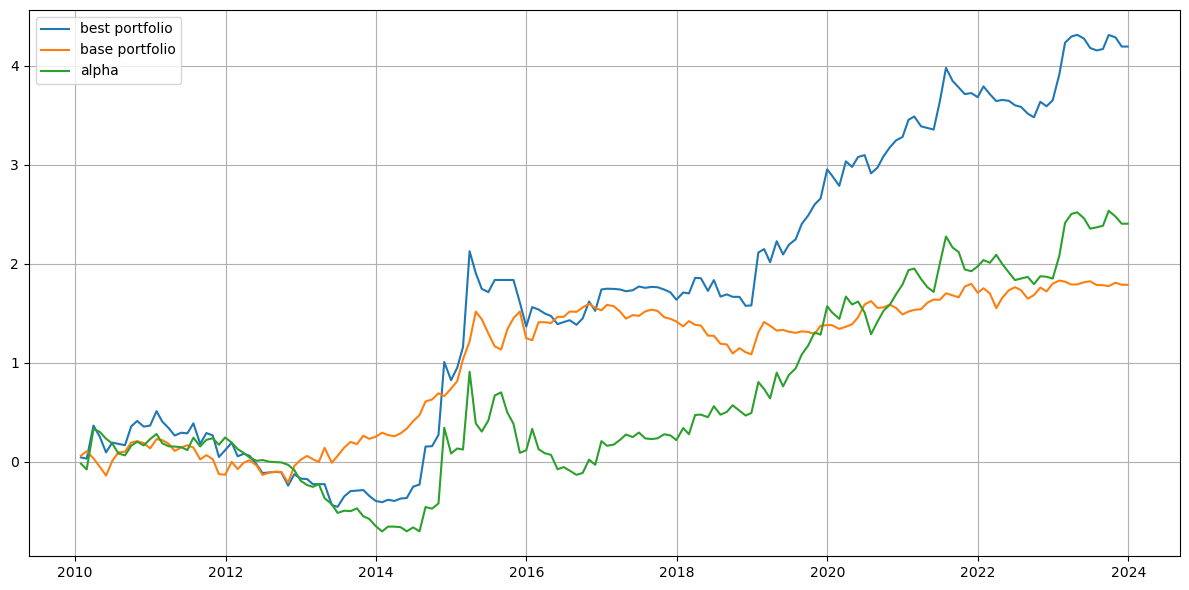

In [16]:
def convert_index_to_datetime(df: pd.DataFrame|pd.Series):
    index = df.index
    # 判断是否是形如 20250101 的整数或字符串格式
    if all(isinstance(i, (int, str)) and len(str(i)) == 8 for i in index):
        try:
            df.index = pd.to_datetime(index, format="%Y%m%d")
        except Exception as e:
            print("转换失败：", e)
    else:
        print("索引不是 yyyymmdd 格式，未做转换")
    return df

w_df = pd.DataFrame(w_dict).T.reindex(index=ret_m.index, columns=ret_m.columns).fillna(0)
w_df_base = pd.DataFrame(w_dict_base).T.reindex(index=ret_m.index, columns=ret_m.columns).fillna(0)
ret_portfolio = convert_index_to_datetime((w_df * ret_m).sum(1))
ret_portfolio_base = convert_index_to_datetime((w_df_base * ret_m).sum(1))
ret_diff = ret_portfolio - ret_portfolio_base

alpha_sharpe = ret_diff.mean() / ret_diff.std() *12**0.5
base_sharpe = ret_portfolio_base.mean() / ret_diff.std() *12**0.5
strategy_sharpe = ret_portfolio.mean() / ret_diff.std() *12**0.5

print("strategy_sharpe", strategy_sharpe)
print("base_sharpe", base_sharpe)
print("alpha_sharpe", alpha_sharpe)

plt.figure(figsize=(12, 6))
plt.plot(ret_portfolio.cumsum(), label="best portfolio")
plt.plot(ret_portfolio_base.cumsum(), label="base portfolio")
plt.plot(ret_diff.cumsum(), label="alpha")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
# w_df

strategy_sharpe 0.7140669460914038
base_sharpe 0.21538205547498357
alpha_sharpe 0.49868489061642


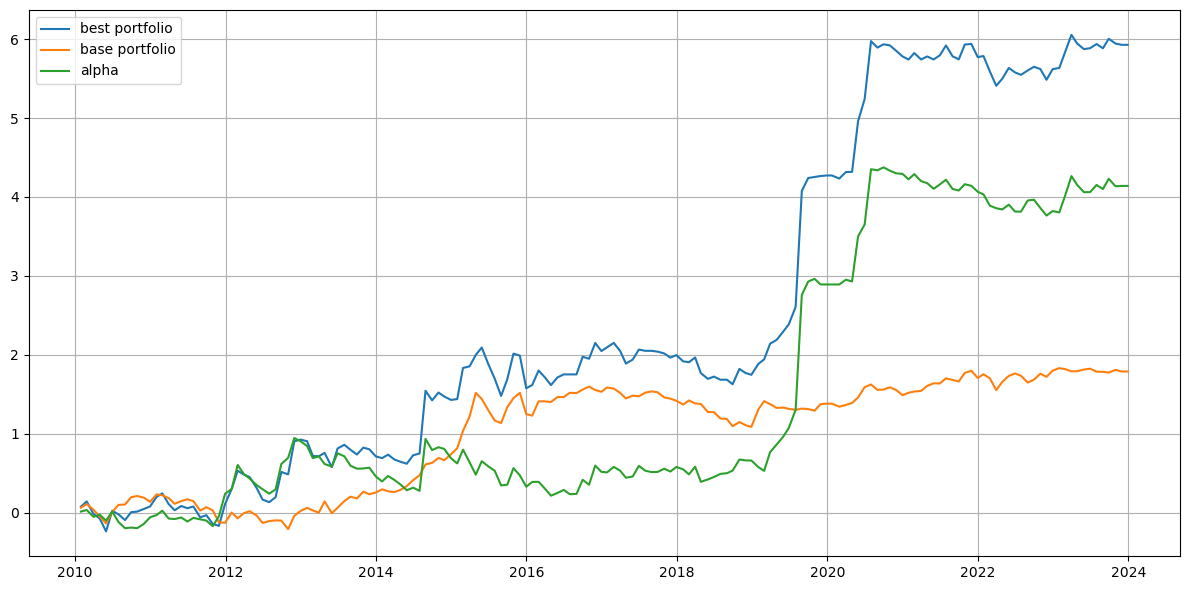

In [ ]:
import pandas as pd
import cvxpy as cp
import numpy as np


data = pd.read_csv("factor_value_fmsq_1Y.csv", index_col=0)
factor = data.reindex(index=ret_m.index, columns=ret_m.columns)
size_factor: pd.DataFrame
# 结果保存
w_dict = {}
w_dict_base = {}

# 遍历每期（按行）
for dt, ret_row in ret_m.iterrows():
    # 1. 选出当期有效的股票（非 NaN）
    valid = ret_row.dropna().index.tolist()

    if len(valid) == 0:
        continue  # 跳过空期

    # 2. 提取因子值  把size factor市值因子拿出来
    f_row = factor.loc[dt].reindex(valid).fillna(0).values  # 因子值
    s_row = size_factor.loc[dt].reindex(valid).fillna(0).values  # ✅ size 因子值
    s_row = s_row / s_row.std()
    n = len(valid)

    # 3. 决策变量：股票权重
    w = cp.Variable(n)

    # 4. 目标函数：最大化 ∑(因子 × 权重)
    obj = cp.Maximize(f_row @ w)

    # 5. 约束：权重非负、权重和为 1（标准 long-only 组合）
    constraints = [
        w >= 0, 
        cp.sum(w) == 1,
        cp.abs(s_row @ w) <= 0.1    # size_factor 中性  定一个范围，而不是sum=1
    ]

    prob = cp.Problem(obj, constraints)

    prob.solve(solver=cp.ECOS)
    if w.value is not None and np.all(np.isfinite(w.value)):
        w_opt = pd.Series(w.value, index=valid)
    else:
        w_opt = pd.Series(np.ones(n) / n, index=valid)  # fallback: 等权

    # 6. 保存结果
    w_dict[dt] = w_opt
    w_dict_base[dt] = pd.Series(np.ones(n) / n, index=valid)

def convert_index_to_datetime(df: pd.DataFrame|pd.Series):
    index = df.index
    # 判断是否是形如 20250101 的整数或字符串格式
    if all(isinstance(i, (int, str)) and len(str(i)) == 8 for i in index):
        try:
            df.index = pd.to_datetime(index, format="%Y%m%d")
        except Exception as e:
            print("转换失败：", e)
    else:
        print("索引不是 yyyymmdd 格式，未做转换")
    return df

w_df = pd.DataFrame(w_dict).T.reindex(index=ret_m.index, columns=ret_m.columns).fillna(0)
w_df_base = pd.DataFrame(w_dict_base).T.reindex(index=ret_m.index, columns=ret_m.columns).fillna(0)
ret_portfolio = convert_index_to_datetime((w_df * ret_m).sum(1))
ret_portfolio_base = convert_index_to_datetime((w_df_base * ret_m).sum(1))
ret_diff = ret_portfolio - ret_portfolio_base

alpha_sharpe = ret_diff.mean()*12**0.5 / ret_diff.std()
base_sharpe = ret_portfolio_base.mean()*12**0.5 / ret_diff.std()
strategy_sharpe = ret_portfolio.mean()*12**0.5 / ret_diff.std()

print("strategy_sharpe", strategy_sharpe)
print("base_sharpe", base_sharpe)
print("alpha_sharpe", alpha_sharpe)

plt.figure(figsize=(12, 6))
plt.plot(ret_portfolio.cumsum(), label="best portfolio")
plt.plot(ret_portfolio_base.cumsum(), label="base portfolio")
plt.plot(ret_diff.cumsum(), label="alpha")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()